<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/99_tsla_after_lecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TSLA 투자 성과 분석

가정:
- 각 강의 **종료 후** 첫 미국 거래일에 TSLA를 매수
- 각 클래스당 **1,000만 원** 투자
- 매수 시점의 원/달러 환율로 환전 후 TSLA 매수
- 현재까지 보유했을 때의 수익률과 평가금액 계산



Current Reference Data
- Latest TSLA date: 2026-03-19, Price: $380.30
- Latest USD/KRW date: 2026-03-19, FX Rate: 1,505.25 KRW

Investment Results by Class


,Class,Lecture Period,Lecture End,Buy Date,Buy TSLA (USD),Buy USD/KRW,Shares Bought,Current TSLA Date,Current TSLA (USD),Current FX Date,Current USD/KRW,Initial KRW,Current Value (KRW),Profit (KRW),Return (%)
0,Class 1,2025-04-05 ~ 2025-04-18,2025-04-18,2025-04-22,237.97,1421.64,29.5589,2026-03-19,380.3,2026-03-19,1505.25,10000000,16920886,6920886,69.2089
1,Class 2,2025-10-11 ~ 2025-10-24,2025-10-24,2025-10-27,452.42,1436.97,15.3819,2026-03-19,380.3,2026-03-19,1505.25,10000000,8805326,-1194674,-11.9467


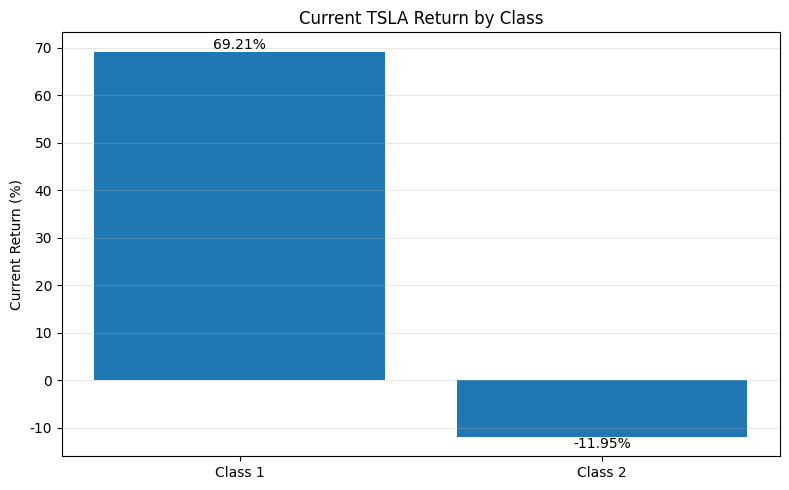

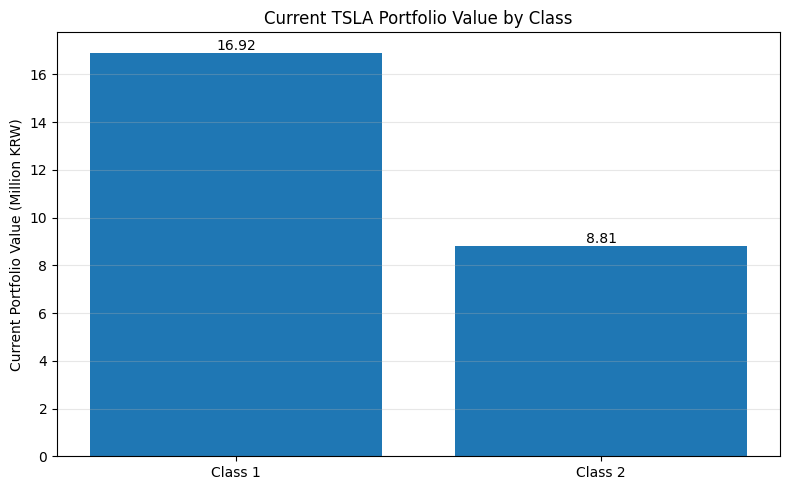

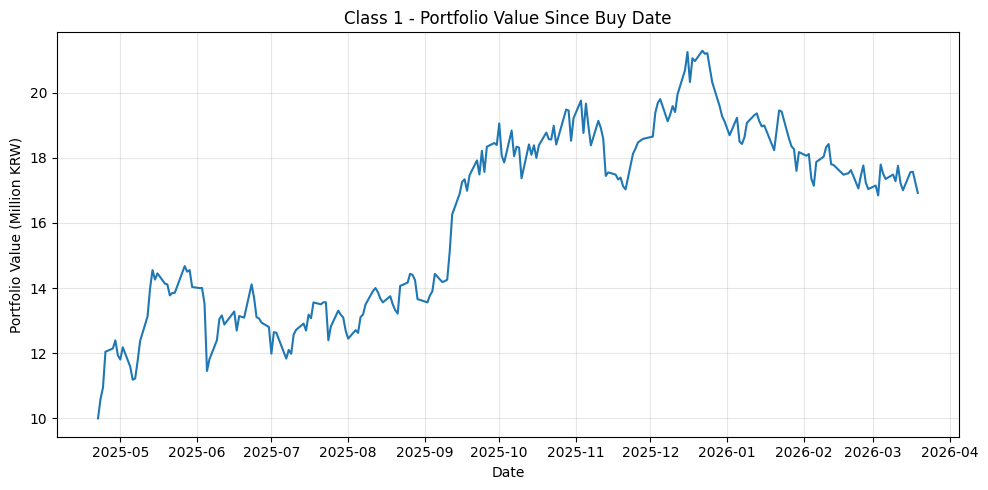

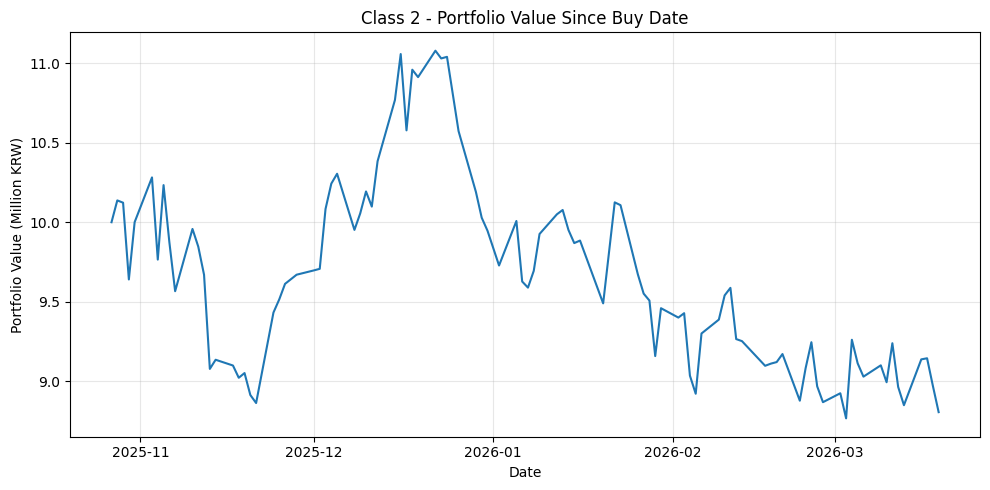

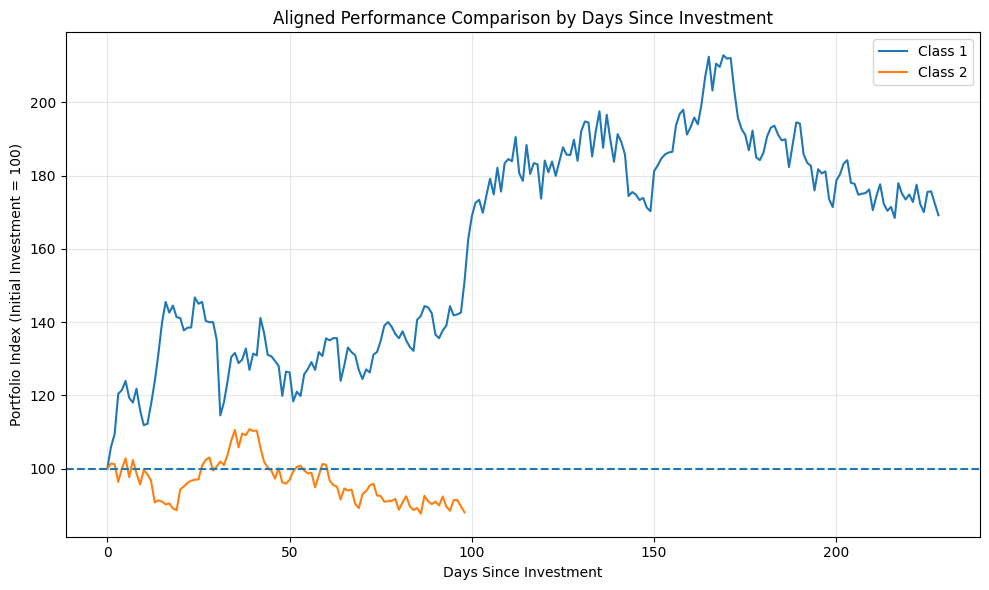

CSV saved:
- tsla_class_after_lecture_returns_fixed.csv
- tsla_portfolio_path_class_1.csv
- tsla_portfolio_path_class_2.csv


In [1]:
# Colab-ready
!pip -q install yfinance

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# =========================================================
# 1. Settings
# =========================================================
INITIAL_KRW = 10_000_000
TSLA_TICKER = "TSLA"
FX_TICKER = "KRW=X"   # Yahoo Finance: KRW per USD

classes = {
    "Class 1": {
        "lecture_period": "2025-04-05 ~ 2025-04-18",
        "lecture_end": "2025-04-18",
    },
    "Class 2": {
        "lecture_period": "2025-10-11 ~ 2025-10-24",
        "lecture_end": "2025-10-24",
    },
}

BUY_FEE_RATE = 0.0
SELL_FEE_RATE = 0.0

# =========================================================
# 2. Helper functions
# =========================================================
def get_single_price_series(ticker: str, start: str, end: str) -> pd.Series:
    df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if df.empty:
        raise ValueError(f"No data downloaded for {ticker}")

    if isinstance(df.columns, pd.MultiIndex):
        if ("Close", ticker) in df.columns:
            s = df[("Close", ticker)].copy()
        elif ("Adj Close", ticker) in df.columns:
            s = df[("Adj Close", ticker)].copy()
        else:
            level0 = df.columns.get_level_values(0)
            if "Close" in level0:
                s = df.xs("Close", axis=1, level=0).iloc[:, 0].copy()
            elif "Adj Close" in level0:
                s = df.xs("Adj Close", axis=1, level=0).iloc[:, 0].copy()
            else:
                raise KeyError(f"Could not find Close/Adj Close for {ticker}")
    else:
        if "Close" in df.columns:
            s = df["Close"].copy()
        elif "Adj Close" in df.columns:
            s = df["Adj Close"].copy()
        else:
            raise KeyError(f"Could not find Close/Adj Close for {ticker}")

    s.name = ticker
    return s.dropna()

def next_trading_day_after(date_str: str, trading_index: pd.DatetimeIndex) -> pd.Timestamp:
    target = pd.Timestamp(date_str) + pd.Timedelta(days=1)
    valid = trading_index[trading_index >= target]
    if len(valid) == 0:
        raise ValueError(f"No trading day found after {date_str}")
    return valid[0]

def latest_available_on_or_before(series: pd.Series, dt: pd.Timestamp):
    s = series[series.index <= dt]
    if s.empty:
        raise ValueError(f"No available value on or before {dt}")
    return float(s.iloc[-1])

# =========================================================
# 3. Download data
# =========================================================
min_start = "2025-04-01"
today = pd.Timestamp.today().normalize() + pd.Timedelta(days=1)

tsla = get_single_price_series(TSLA_TICKER, min_start, today.strftime("%Y-%m-%d"))
fx = get_single_price_series(FX_TICKER, min_start, today.strftime("%Y-%m-%d"))

# Align price and FX series
market = pd.concat([tsla, fx], axis=1).dropna()
market.columns = ["TSLA_USD", "USDKRW"]

current_tsla = float(market["TSLA_USD"].iloc[-1])
current_tsla_date = market.index[-1].date()
current_usdkrw = float(market["USDKRW"].iloc[-1])
current_fx_date = market.index[-1].date()

# =========================================================
# 4. Calculate investment performance by class
# =========================================================
rows = []
portfolio_paths = {}

for class_name, info in classes.items():
    lecture_end = info["lecture_end"]
    buy_date = next_trading_day_after(lecture_end, market.index)

    buy_tsla_usd = float(market.loc[buy_date, "TSLA_USD"])
    buy_usdkrw = float(market.loc[buy_date, "USDKRW"])

    usd_after_fx = INITIAL_KRW / buy_usdkrw
    usd_after_buy_fee = usd_after_fx * (1 - BUY_FEE_RATE)
    shares = usd_after_buy_fee / buy_tsla_usd

    # Daily portfolio path after purchase
    path = market.loc[market.index >= buy_date].copy()
    path["Portfolio_Value_KRW"] = shares * path["TSLA_USD"] * path["USDKRW"] * (1 - SELL_FEE_RATE)
    path["Return_Pct"] = (path["Portfolio_Value_KRW"] / INITIAL_KRW - 1) * 100
    path["Days_Since_Investment"] = range(len(path))
    portfolio_paths[class_name] = path

    current_value_krw = float(path["Portfolio_Value_KRW"].iloc[-1])
    profit_krw = current_value_krw - INITIAL_KRW
    return_pct = (current_value_krw / INITIAL_KRW - 1) * 100

    rows.append({
        "Class": class_name,
        "Lecture Period": info["lecture_period"],
        "Lecture End": lecture_end,
        "Buy Date": buy_date.date(),
        "Buy TSLA (USD)": buy_tsla_usd,
        "Buy USD/KRW": buy_usdkrw,
        "Shares Bought": shares,
        "Current TSLA Date": current_tsla_date,
        "Current TSLA (USD)": current_tsla,
        "Current FX Date": current_fx_date,
        "Current USD/KRW": current_usdkrw,
        "Initial KRW": INITIAL_KRW,
        "Current Value (KRW)": current_value_krw,
        "Profit (KRW)": profit_krw,
        "Return (%)": return_pct,
    })

result = pd.DataFrame(rows)

result_display = result.copy()
for col in ["Buy TSLA (USD)", "Buy USD/KRW", "Shares Bought", "Current TSLA (USD)", "Current USD/KRW", "Return (%)"]:
    result_display[col] = result_display[col].astype(float).round(4)

for col in ["Initial KRW", "Current Value (KRW)", "Profit (KRW)"]:
    result_display[col] = result_display[col].round(0).astype(int)

print("Current Reference Data")
print(f"- Latest TSLA date: {current_tsla_date}, Price: ${current_tsla:,.2f}")
print(f"- Latest USD/KRW date: {current_fx_date}, FX Rate: {current_usdkrw:,.2f} KRW")
print()
print("Investment Results by Class")
display(result_display)

# =========================================================
# 5. Chart 1: Current return by class
# =========================================================
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 5))
plt.bar(result["Class"], result["Return (%)"])
plt.ylabel("Current Return (%)")
plt.title("Current TSLA Return by Class")
plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(result["Return (%)"]):
    plt.text(i, v, f"{v:.2f}%", ha="center", va="bottom" if v >= 0 else "top")
plt.tight_layout()
plt.show()

# =========================================================
# 6. Chart 2: Current portfolio value by class
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(result["Class"], result["Current Value (KRW)"] / 1_000_000)
plt.ylabel("Current Portfolio Value (Million KRW)")
plt.title("Current TSLA Portfolio Value by Class")
plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(result["Current Value (KRW)"] / 1_000_000):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# =========================================================
# 7. Separate chart for each class (calendar dates)
#    This fixes the issue of forcing different buy dates into one calendar comparison
# =========================================================
for class_name, path in portfolio_paths.items():
    plt.figure(figsize=(10, 5))
    plt.plot(path.index, path["Portfolio_Value_KRW"] / 1_000_000)
    plt.ylabel("Portfolio Value (Million KRW)")
    plt.xlabel("Date")
    plt.title(f"{class_name} - Portfolio Value Since Buy Date")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# 8. Optional fair comparison chart:
#    align both investments by "Days Since Investment"
# =========================================================
aligned = pd.DataFrame()
for class_name, path in portfolio_paths.items():
    temp = path[["Days_Since_Investment", "Portfolio_Value_KRW"]].copy()
    temp = temp.set_index("Days_Since_Investment")
    aligned[class_name] = temp["Portfolio_Value_KRW"] / INITIAL_KRW * 100

plt.figure(figsize=(10, 6))
for col in aligned.columns:
    plt.plot(aligned.index, aligned[col], label=col)
plt.axhline(100, linestyle="--")
plt.ylabel("Portfolio Index (Initial Investment = 100)")
plt.xlabel("Days Since Investment")
plt.title("Aligned Performance Comparison by Days Since Investment")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 9. Save CSV files
# =========================================================
result_display.to_csv("tsla_class_after_lecture_returns_fixed.csv", index=False, encoding="utf-8-sig")

for class_name, path in portfolio_paths.items():
    safe_name = class_name.lower().replace(" ", "_")
    save_df = path.copy()
    save_df.to_csv(f"tsla_portfolio_path_{safe_name}.csv", encoding="utf-8-sig")

print("CSV saved:")
print("- tsla_class_after_lecture_returns_fixed.csv")
for class_name in portfolio_paths.keys():
    safe_name = class_name.lower().replace(" ", "_")
    print(f"- tsla_portfolio_path_{safe_name}.csv")
